## Can a computer learn if we are going to detect gravitational waves? (Part 2)
 In order to decide if a feature in the observed population of objects is telling us something new about reality, we need to understand and model our **selection effects**.

 In observational astronomy, this is known as **Malmquist bias** and was first formulated in 1922.

 The goal here is to learn the **LIGO detectability** using a neural network: can we predict if a gravitational-wave source will be detected?

### Libraries and Collecting Data

In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121


In [2]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 15.7 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split

In [4]:
import optuna

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import h5py

In [6]:
import os
import time
import warnings
warnings.filterwarnings("ignore")

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, classification_report

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
drive_path = "/content/drive/MyDrive/AstroStats/"
file_path = os.path.join(drive_path, "sample_2e7_design_precessing_higherordermodes_3detectors.h5")

In [10]:
# Exploring the datafile categories
names = []
with h5py.File(file_path, 'r') as f:
  for key in f.keys():
    names.append(key)

In [11]:
print(names)

['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']


In [12]:
# Extrapolating data
data = []
with h5py.File(file_path, 'r') as f:
  for key in names:
    temp_data = f[key][:]
    data.append(temp_data)

In [13]:
# Creating a dataframe for more visibility
table = pd.DataFrame(np.array(data).T, columns=names)

This dataset contains simulated gravitational-wave signals from merging black holes.

In particular, each source has the following features:
1. **mtot**: the total mass of the binary
2. **q**: the mass ratio
3. **chi1x, chi1y, chi1z, chi2x, chi2y, chi2z**: the components of the black-hole spins in a suitable reference frame
4. **ra, dec**: the location of the source in the sky
5. **iota**: the inclination of the orbital plane
6. **psi**: the polarization angle (gravitational waves have two polarization states much like light)
7. **z**: the redshift

The detectability is defined using the **snr** (signal-to-noise ratio) computed with a state-of-the-art model of the LIGO/Virgo detector network.

All you need to know now is that we threshold the snr values and assume that LIGO will (not) see a source if snr > 12 (snr < 12).

The resulting 0-1 labels are reported in the **det** attribute in the dataset.

In [14]:
table

,chi1x,chi1y,chi1z,chi2x,chi2y,chi2z,dec,det,iota,mtot,psi,q,ra,snr,z
0,-0.307201,0.276165,-0.430760,-0.161114,-0.092334,-0.414647,-0.329671,0.0,1.809310,906.803562,1.286031,0.624780,-3.116784,0.822509,2.139659
1,-0.734712,-0.498493,-0.298162,0.057532,-0.844992,0.014708,0.526740,0.0,0.820820,59.102112,0.934308,0.986650,1.360291,1.093237,2.438707
2,-0.057831,-0.703796,-0.354512,-0.215538,0.016323,0.130543,0.315799,0.0,2.008206,44.602750,1.535520,0.286199,0.079973,1.305398,1.869461
3,0.015260,-0.202467,-0.492768,-0.237033,-0.365363,-0.876192,0.432105,0.0,2.018398,534.378032,3.064086,0.538882,-1.780558,9.112974,0.428061
4,-0.016731,0.007848,0.005007,0.147519,0.231879,0.086716,-0.458711,1.0,2.037363,573.821705,0.752211,0.846310,2.789289,17.525534,0.772609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19999995,-0.192062,-0.132125,0.099840,0.244232,-0.610395,0.205643,0.227502,0.0,1.712124,47.173930,0.458902,0.721899,2.747641,0.550924,2.942686
19999996,-0.004265,-0.056190,-0.030455,0.080665,-0.263666,-0.028503,-0.289584,0.0,1.796748,319.515160,2.011788,0.276340,-3.010306,6.303695,1.348554
19999997,-0.558253,-0.107589,0.065246,0.305706,-0.212490,-0.412048,-0.236878,0.0,0.894741,536.491292,1.776291,0.909982,-1.638381,9.975289,0.826640
19999998,0.084775,-0.042762,0.017719,0.145657,0.474321,0.744677,0.104063,0.0,1.102068,879.055152,1.317251,0.287587,2.211932,0.920406,3.125594


### PyTorch (run on Google Colab)

**Tasks**

- Scale your data appropriately.

- Decide on a testing strategy (a simple test/train split or a CV strategy).

- Decide your optimization metric.

- Write down your network architecture. You can start from a fully connected, multi-layer perceptron. Use one of the packages we have seen (tensorflow via keras, pytorch, or the MPL classifier implemented in scikit-learn).

- Optimize the hyperparameters of your network. If it takes too long, run the hyperparameter optimization on a subset of the training set. Then retrain the full network using the best hyperparameters only.

- Report the perfomance of the network on the test dataset. Print out the classification score for the training dataset, and the best parameters obtained by the cross-validation.

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [16]:
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("CUDA runtime version:", torch.version.cuda)

GPU name: Tesla T4
CUDA runtime version: 12.6


In [17]:
# Computational speed test
size = (10000, 10000)

# --- Test CPU ---
x_cpu = torch.randn(size)
y_cpu = torch.randn(size)

start_cpu = time.time()
z_cpu = x_cpu @ y_cpu  # Matrix product
torch.cuda.synchronize() if torch.cuda.is_available() else None
end_cpu = time.time()
print(f"CPU: {end_cpu - start_cpu:.4f} s")

# --- Test GPU ---
if torch.cuda.is_available():
    device = torch.device("cuda")
    x_gpu = x_cpu.to(device)
    y_gpu = y_cpu.to(device)

    torch.cuda.synchronize()
    start_gpu = time.time()
    z_gpu = x_gpu @ y_gpu
    torch.cuda.synchronize()
    end_gpu = time.time()
    print(f"GPU: {end_gpu - start_gpu:.4f} s")
else:
    print("No GPU available")

CPU: 17.4742 s
GPU: 0.7302 s


In [18]:
# Let's downsample the data since there isn't enough RAM memory
sel_table = table.sample(frac=0.1, random_state=123)

In [19]:
feature_table = sel_table.drop(columns=['snr', 'det'])

In [20]:
# Formatting data with the sklearn style
X = np.array(feature_table.values)
X_names = np.array(feature_table.columns)
y = np.array(sel_table['det'].values)

In [21]:
print(X_names)
print(X.shape)
print(y.shape)

['chi1x' 'chi1y' 'chi1z' 'chi2x' 'chi2y' 'chi2z' 'dec' 'iota' 'mtot' 'psi'
 'q' 'ra' 'z']
(2000000, 13)
(2000000,)


In [22]:
# Split the dataset in tranining + test dataset
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(X, y, range(len(X)), test_size=0.25, random_state=42)

In [23]:
# Normalizing data
scaler = StandardScaler()
X_std_train = scaler.fit_transform(X_train)
X_std_test = scaler.transform(X_test)

In [24]:
print(X_std_train.shape)
print(y_train.shape)
print(X_std_test.shape)
print(y_test.shape)

(1500000, 13)
(1500000,)
(500000, 13)
(500000,)


In [25]:
# Now convert datasets into PyTorch tensors
X_train_tensor = torch.tensor(X_std_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

X_test_tensor = torch.tensor(X_std_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [26]:
# Loaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

#### Autoencoder

In [27]:
# The autoencoder learns to reconstruct inputs and produce compressed latent features
class Autoencoder(nn.Module):
    def __init__(self, input_dim=13, latent_dim=11):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 12),
            nn.ReLU(),
            nn.Linear(12, latent_dim)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 12),
            nn.ReLU(),
            nn.Linear(12, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

In [28]:
# Creating a validation subset for the early stopping procedure
full_dataset = train_loader.dataset
val_fraction = 0.2
val_size = int(len(full_dataset) * val_fraction)
train_size = len(full_dataset) - val_size
gen = torch.Generator().manual_seed(42)
train_subset, val_subset = random_split(full_dataset, [train_size, val_size], generator=gen)

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=128, shuffle=False)

In [29]:
# Define a python function to perform hyperparameters tuning
def train_autoencoder(lr=0.01, weight_decay=0.01, patience=10, device='cuda'):
    # Initialize model
    autoencoder = Autoencoder().to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(autoencoder.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_loss = float('inf')
    counter = 0
    best_model_wts = None

    for epoch in range(200):
        # ----- TRAINING -----
        autoencoder.train()
        total_train_loss = 0
        for X_batch, _ in train_loader:
            X_batch = X_batch.to(device)
            optimizer.zero_grad()
            recon = autoencoder(X_batch)
            loss = criterion(recon, X_batch)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
        avg_train_loss = total_train_loss / len(train_loader)

        # ----- VALIDATION -----
        autoencoder.eval()
        total_val_loss = 0
        with torch.no_grad():
            for X_val, _ in val_loader:
                X_val = X_val.to(device)
                recon_val = autoencoder(X_val)
                val_loss = criterion(recon_val, X_val)
                total_val_loss += val_loss.item()
        avg_val_loss = total_val_loss / len(val_loader)

        # Logging
        print(f"Epoch [{epoch+1}/200] - Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

        # ----- EARLY STOPPING -----
        if avg_val_loss < best_val_loss * (1 - 1e-3):
            best_val_loss = avg_val_loss
            counter = 0
            best_model_wts = autoencoder.state_dict()
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # Reload best weights
    if best_model_wts is not None:
        autoencoder.load_state_dict(best_model_wts)

    return best_val_loss, autoencoder

In [ ]:
def objective(trial):
    lr = trial.suggest_loguniform('lr', 1e-4, 1e-2)
    weight_decay = trial.suggest_loguniform('weight_decay', 1e-5, 1e-2)
    patience = trial.suggest_int('patience', 5, 15)
    val_loss, _ = train_autoencoder(lr=lr, weight_decay=weight_decay, patience=patience)
    return val_loss

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

[I 2025-11-13 15:41:21,351] A new study created in memory with name: no-name-910f6eea-24ed-4ba6-ba11-c2f63a12bfbd


Epoch [1/200] - Train Loss: 0.205808 | Val Loss: 0.153978
Epoch [2/200] - Train Loss: 0.154495 | Val Loss: 0.154824
Epoch [3/200] - Train Loss: 0.154375 | Val Loss: 0.153858
Epoch [4/200] - Train Loss: 0.154324 | Val Loss: 0.153941
Epoch [5/200] - Train Loss: 0.154246 | Val Loss: 0.154429
Epoch [6/200] - Train Loss: 0.154187 | Val Loss: 0.154269


[I 2025-11-13 15:44:44,098] Trial 0 finished with value: 0.15397823497703864 and parameters: {'lr': 0.0007261427678093969, 'weight_decay': 2.0381969663444364e-05, 'patience': 6}. Best is trial 0 with value: 0.15397823497703864.


Epoch [7/200] - Train Loss: 0.154141 | Val Loss: 0.154195
Early stopping at epoch 7
Epoch [1/200] - Train Loss: 0.341652 | Val Loss: 0.235583
Epoch [2/200] - Train Loss: 0.189103 | Val Loss: 0.159671
Epoch [3/200] - Train Loss: 0.157924 | Val Loss: 0.157827
Epoch [4/200] - Train Loss: 0.156772 | Val Loss: 0.157064
Epoch [5/200] - Train Loss: 0.156492 | Val Loss: 0.156940
Epoch [6/200] - Train Loss: 0.156373 | Val Loss: 0.156841
Epoch [7/200] - Train Loss: 0.156293 | Val Loss: 0.156844
Epoch [8/200] - Train Loss: 0.156239 | Val Loss: 0.156766
Epoch [9/200] - Train Loss: 0.156201 | Val Loss: 0.156736
Epoch [10/200] - Train Loss: 0.156189 | Val Loss: 0.156805
Epoch [11/200] - Train Loss: 0.156167 | Val Loss: 0.156910
Epoch [12/200] - Train Loss: 0.156157 | Val Loss: 0.156824
Epoch [13/200] - Train Loss: 0.156135 | Val Loss: 0.156803
Epoch [14/200] - Train Loss: 0.156122 | Val Loss: 0.156819
Epoch [15/200] - Train Loss: 0.156114 | Val Loss: 0.156692
Epoch [16/200] - Train Loss: 0.156103 | 

[I 2025-11-13 16:01:08,974] Trial 1 finished with value: 0.15665270962494937 and parameters: {'lr': 0.0005340875488562088, 'weight_decay': 0.0015684333372313456, 'patience': 16}. Best is trial 0 with value: 0.15397823497703864.


...

Epoch [25/200] - Train Loss: 0.153816 | Val Loss: 0.154433
Early stopping at epoch 25
Epoch [1/200] - Train Loss: 0.172273 | Val Loss: 0.154326
Epoch [2/200] - Train Loss: 0.154668 | Val Loss: 0.155105
Epoch [3/200] - Train Loss: 0.154466 | Val Loss: 0.154660
Epoch [4/200] - Train Loss: 0.154411 | Val Loss: 0.155057
Epoch [5/200] - Train Loss: 0.154379 | Val Loss: 0.154928
Epoch [6/200] - Train Loss: 0.154329 | Val Loss: 0.153923
Epoch [7/200] - Train Loss: 0.154317 | Val Loss: 0.154482
Epoch [8/200] - Train Loss: 0.154276 | Val Loss: 0.154265
Epoch [9/200] - Train Loss: 0.154290 | Val Loss: 0.154231
Epoch [10/200] - Train Loss: 0.154284 | Val Loss: 0.154248
Epoch [11/200] - Train Loss: 0.154290 | Val Loss: 0.154721
Epoch [12/200] - Train Loss: 0.154262 | Val Loss: 0.153878
Epoch [13/200] - Train Loss: 0.154261 | Val Loss: 0.153845
Epoch [14/200] - Train Loss: 0.154257 | Val Loss: 0.154091
Epoch [15/200] - Train Loss: 0.154228 | Val Loss: 0.153819


[I 2025-11-13 16:41:30,510] Trial 6 finished with value: 0.1539225539593058 and parameters: {'lr': 0.0029993035119063693, 'weight_decay': 2.1935789833856334e-05, 'patience': 10}. Best is trial 6 with value: 0.1539225539593058.


Epoch [16/200] - Train Loss: 0.154235 | Val Loss: 0.153957
Early stopping at epoch 16
Epoch [1/200] - Train Loss: 0.171057 | Val Loss: 0.155206
Epoch [2/200] - Train Loss: 0.154718 | Val Loss: 0.152442
Epoch [3/200] - Train Loss: 0.152965 | Val Loss: 0.152517
Epoch [4/200] - Train Loss: 0.152846 | Val Loss: 0.153255
Epoch [5/200] - Train Loss: 0.152734 | Val Loss: 0.152590
Epoch [6/200] - Train Loss: 0.152702 | Val Loss: 0.152849
Epoch [7/200] - Train Loss: 0.152692 | Val Loss: 0.154175
Epoch [8/200] - Train Loss: 0.152680 | Val Loss: 0.153587
Epoch [9/200] - Train Loss: 0.152632 | Val Loss: 0.152888


[W 2025-11-13 16:46:33,109] Trial 7 failed with parameters: {'lr': 0.003108200493157288, 'weight_decay': 0.000214242464194983, 'patience': 11} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipython-input-2817549748.py", line 5, in objective
    return train_autoencoder(lr=lr, weight_decay=weight_decay, patience=patience)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-3050462151.py", line 21, in train_autoencoder
    loss.backward()
  File "/usr/local/lib/python3.12/dist-packages/torch/_tensor.py", line 647, in backward
    torch.autograd.backward(
  File "/usr/local/lib/python3.12/dist-packages/torch/autograd/__init__.py", line 354, in backward
    _engine_run_backward(
  File "/usr/local/lib/python3.12/dis

KeyboardInterrupt: 

In [ ]:
print("Best hyperparameters:", study.best_trial.params)

Best hyperparameters: {'lr': 0.0029993035119063693, 'weight_decay': 2.1935789833856334e-05, 'patience': 10}


In [30]:
# best_params = study.best_trial.params
best_params = {'lr': 0.003, 'weight_decay': 2.2e-5, 'patience': 10}
best_loss, autoencoder = train_autoencoder(**best_params)
print("Final best validation loss:", best_loss)

Epoch [1/200] - Train Loss: 0.171765 | Val Loss: 0.155187
Epoch [2/200] - Train Loss: 0.154606 | Val Loss: 0.154511
Epoch [3/200] - Train Loss: 0.154415 | Val Loss: 0.154013
Epoch [4/200] - Train Loss: 0.154335 | Val Loss: 0.154525
Epoch [5/200] - Train Loss: 0.154229 | Val Loss: 0.154070
Epoch [6/200] - Train Loss: 0.154190 | Val Loss: 0.154083
Epoch [7/200] - Train Loss: 0.154208 | Val Loss: 0.155592
Epoch [8/200] - Train Loss: 0.154137 | Val Loss: 0.155528
Epoch [9/200] - Train Loss: 0.154112 | Val Loss: 0.154937
Epoch [10/200] - Train Loss: 0.154113 | Val Loss: 0.155729
Epoch [11/200] - Train Loss: 0.154090 | Val Loss: 0.154110
Epoch [12/200] - Train Loss: 0.154087 | Val Loss: 0.154705
Epoch [13/200] - Train Loss: 0.154081 | Val Loss: 0.154861
Early stopping at epoch 13
Final best validation loss: 0.15401284405230561


In [31]:
autoencoder.eval()
with torch.no_grad():
    X_train_latent = autoencoder.encoder(X_train_tensor.to(device)).cpu()
    X_test_latent  = autoencoder.encoder(X_test_tensor.to(device)).cpu()

In [32]:
print(X_train_latent.shape)
print(X_test_latent.shape)

torch.Size([1500000, 11])
torch.Size([500000, 11])


In [33]:
# Convert to numpy for some visualization
X_torch = X_test_latent.cpu().numpy()
y_true_torch = y_test_tensor.cpu().numpy()

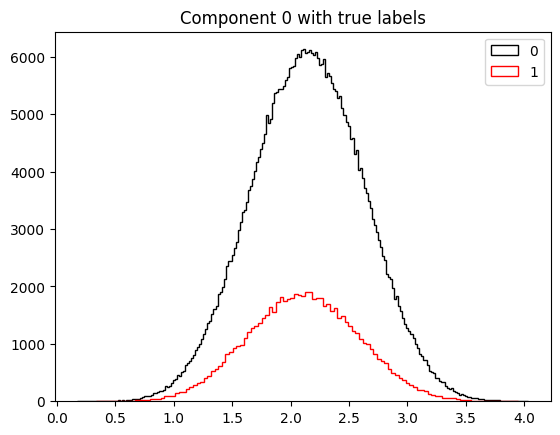

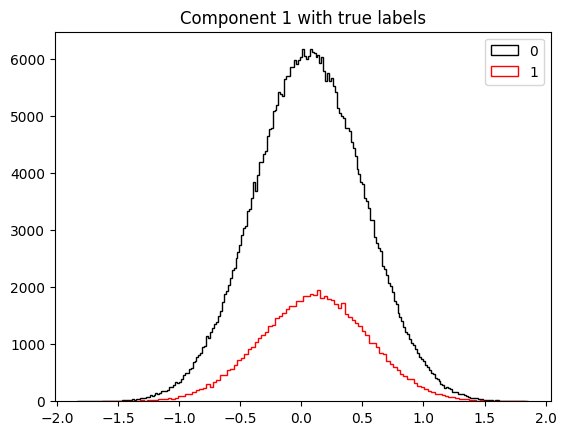

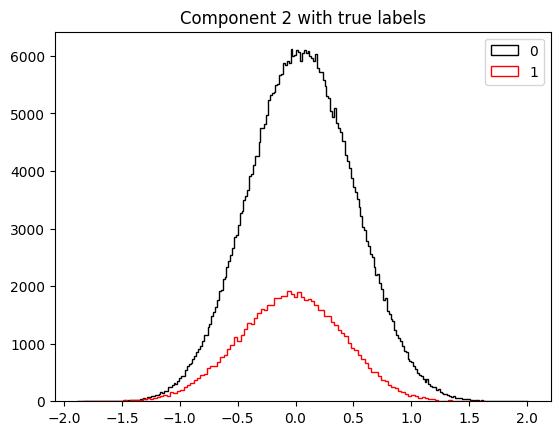

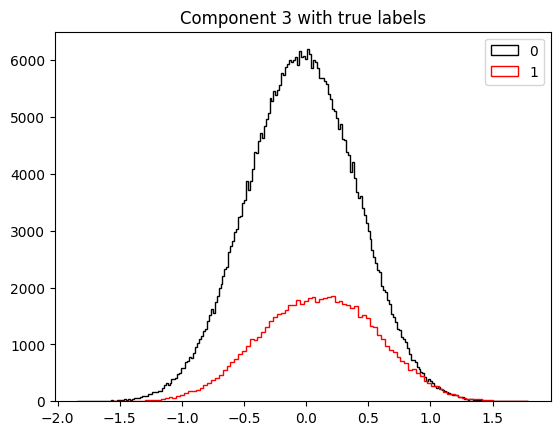

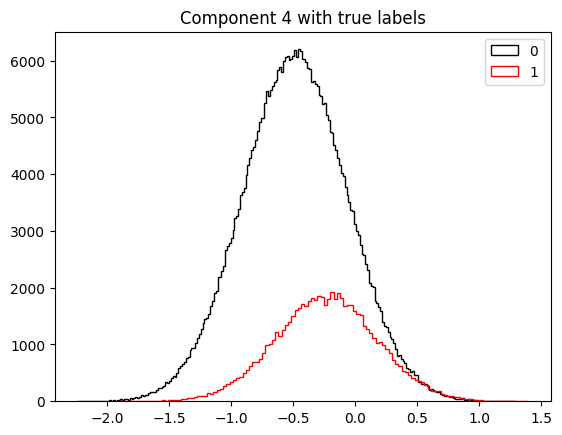

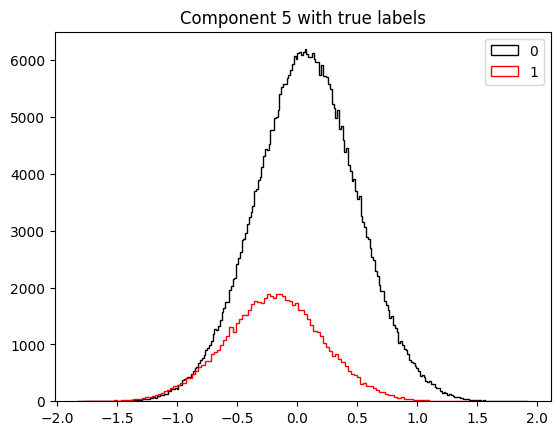

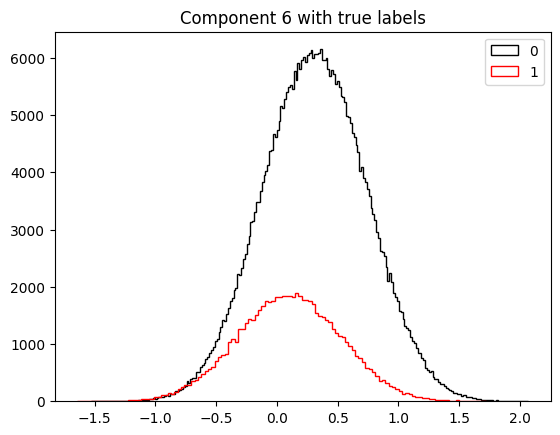

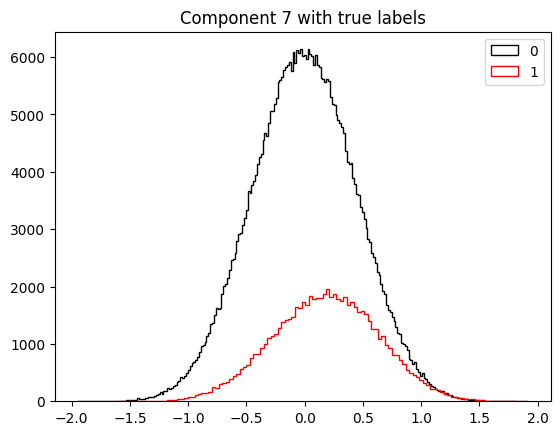

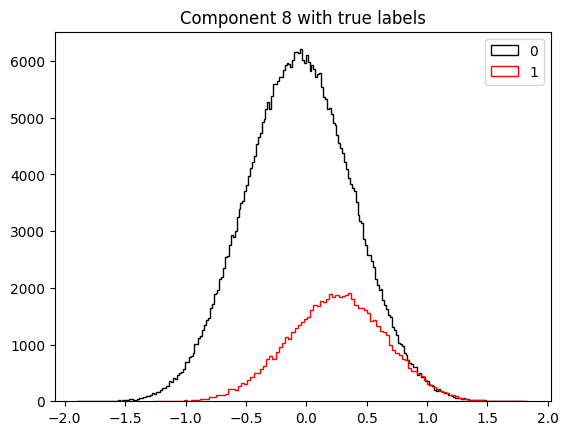

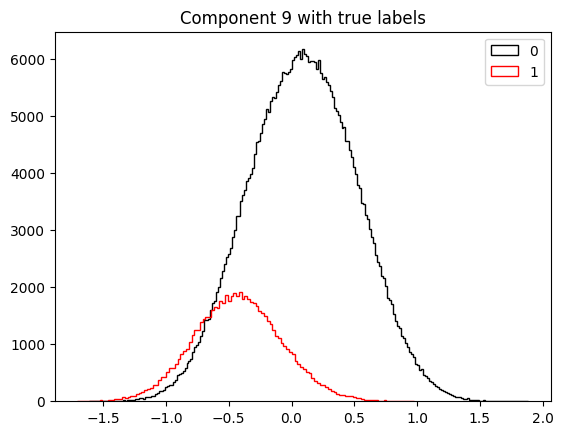

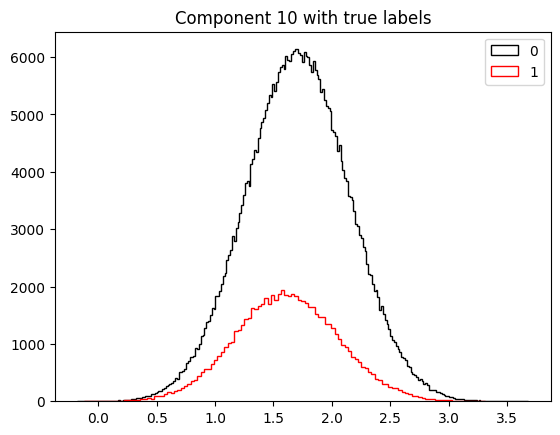

In [34]:
for i in range(11):
  plt.hist(X_torch[:, i].flatten()[y_true_torch==0], bins="auto", histtype='step', color='black', label="0")
  plt.hist(X_torch[:, i].flatten()[y_true_torch==1], bins="auto", histtype='step', color='red', label="1")
  plt.legend()
  plt.title(f"Component {i} with true labels")
  plt.show()
  plt.close()

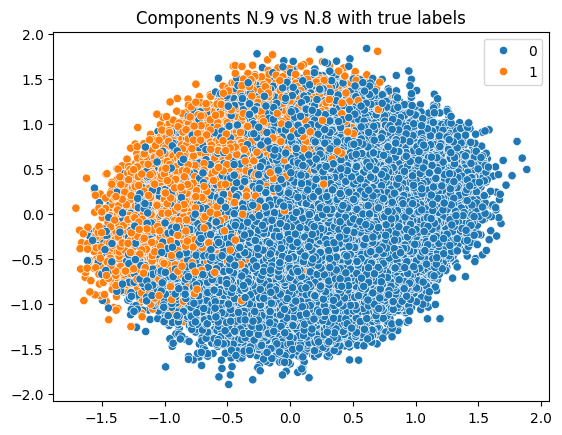

In [35]:
i, j = np.random.choice(range(11), 2, replace=False)
sns.scatterplot(x=X_torch[:, i], y=X_torch[:, j], hue=y_true_torch)
plt.title(f"Components N.{i} vs N.{j} with true labels")
plt.show()
plt.close()

#### MLP

In [39]:
# Now train a fully-connected neural network (a MLP) with the reduced dataset
class MLP(nn.Module):
    def __init__(self, input_dim=11, hidden1_dim=30, drop1=0.0, hidden2_dim=10, drop2=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1_dim),
            nn.ReLU(),
            nn.Dropout(p=drop1),
            nn.Linear(hidden1_dim, hidden2_dim),
            nn.ReLU(),
            nn.Dropout(p=drop2),
            nn.Linear(hidden2_dim, 2)
        ) # "Two layers can represent arbitrary decision boundaries for smooth functions"

    def forward(self, x):
        return self.net(x)

In [37]:
# Creating a validation subset for the early stopping procedure
train_latent_loader = DataLoader(TensorDataset(X_train_latent, y_train_tensor), batch_size=128, shuffle=True)
full_dataset_latent = train_latent_loader.dataset

val_fraction = 0.2
val_size = int(len(full_dataset_latent) * val_fraction)
train_size = len(full_dataset_latent) - val_size

train_latent_subset, val_latent_subset = random_split(full_dataset_latent, [train_size, val_size], generator=gen)

train_latent_loader = DataLoader(train_latent_subset, batch_size=128, shuffle=True)
val_latent_loader = DataLoader(val_latent_subset, batch_size=128, shuffle=False)


In [40]:
# Define a python function to perform hyperparameters tuning
def train_mlp(lr=0.01, weight_decay=0.01, hidden1_dim=30, drop1=0.0, hidden2_dim=10, drop2=0.0, patience=10, device='cuda'):
    # Initialize model
    mlp_torch = MLP(input_dim=11, hidden1_dim=hidden1_dim, drop1=drop1, hidden2_dim=hidden2_dim, drop2=drop2).to(device)
    criterion_mlp = nn.CrossEntropyLoss()
    optimizer_mlp = optim.Adam(mlp_torch.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_loss_mlp = float('inf')
    counter = 0
    best_model_mlp = None

    for epoch in range(200):
        # ----- TRAINING -----
        mlp_torch.train()
        total_train_loss_mlp = 0
        for X_batch, y_batch in train_latent_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer_mlp.zero_grad()
            outputs_mlp = mlp_torch(X_batch)
            loss_mlp = criterion_mlp(outputs_mlp, y_batch)
            loss_mlp.backward()
            optimizer_mlp.step()
            total_train_loss_mlp += loss_mlp.item()
        avg_train_loss_mlp = total_train_loss_mlp / len(train_latent_loader)

        # ----- VALIDATION -----
        mlp_torch.eval()
        total_val_loss_mlp = 0
        with torch.no_grad():
            for X_val, y_val in val_latent_loader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                outputs_val = mlp_torch(X_val)
                val_loss_mlp = criterion_mlp(outputs_val, y_val)
                total_val_loss_mlp += val_loss_mlp.item()
        avg_val_loss_mlp = total_val_loss_mlp / len(val_latent_loader)

        print(f"Epoch [{epoch+1}/200] with h1={hidden1_dim}, h2={hidden2_dim} "
              f"- Train Loss: {avg_train_loss_mlp:.6f} | Val Loss: {avg_val_loss_mlp:.6f}")

        # ----- EARLY STOPPING -----
        if avg_val_loss_mlp < best_val_loss_mlp * (1 - 1e-3):
            best_val_loss_mlp = avg_val_loss_mlp
            counter = 0
            best_model_mlp = mlp_torch.state_dict()
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # Reload best weights
    if best_model_mlp is not None:
        mlp_torch.load_state_dict(best_model_mlp)

    return best_val_loss_mlp, mlp_torch

In [41]:
def objective_mlp(trial):
    hidden1_dim = trial.suggest_int("hidden1_dim", 16, 64)
    hidden2_dim = trial.suggest_int("hidden2_dim", 8, 32)
    while(hidden2_dim > hidden1_dim):
        hidden1_dim = trial.suggest_int("hidden1_dim", 16, 64)
        hidden2_dim = trial.suggest_int("hidden2_dim", 8, 32)
    drop1 = trial.suggest_float("drop1", 0.0, 0.5)
    drop2 = trial.suggest_float("drop2", 0.0, 0.5)
    lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)
    weight_decay = trial.suggest_loguniform("weight_decay", 1e-5, 1e-2)
    patience = trial.suggest_int("patience", 5, 15)
    val_loss, _ = train_mlp(lr=lr, weight_decay=weight_decay, hidden1_dim=hidden1_dim, drop1=drop1, hidden2_dim=hidden2_dim, drop2=drop2, patience=patience)
    return val_loss

study_mlp = optuna.create_study(direction="minimize")
study_mlp.optimize(objective_mlp, n_trials=5)

[I 2025-11-15 18:56:10,379] A new study created in memory with name: no-name-bdbfd2fc-3db3-4ffd-b26e-3b119b19e2c0


Epoch [1/200] with h1=61, h2=9 - Train Loss: 0.128647 | Val Loss: 0.112519
Epoch [2/200] with h1=61, h2=9 - Train Loss: 0.120804 | Val Loss: 0.112459
Epoch [3/200] with h1=61, h2=9 - Train Loss: 0.119660 | Val Loss: 0.107831
Epoch [4/200] with h1=61, h2=9 - Train Loss: 0.119295 | Val Loss: 0.110259
Epoch [5/200] with h1=61, h2=9 - Train Loss: 0.119412 | Val Loss: 0.107241
Epoch [6/200] with h1=61, h2=9 - Train Loss: 0.119071 | Val Loss: 0.114221
Epoch [7/200] with h1=61, h2=9 - Train Loss: 0.119427 | Val Loss: 0.108684
Epoch [8/200] with h1=61, h2=9 - Train Loss: 0.119125 | Val Loss: 0.109476
Epoch [9/200] with h1=61, h2=9 - Train Loss: 0.119052 | Val Loss: 0.107162
Epoch [10/200] with h1=61, h2=9 - Train Loss: 0.119477 | Val Loss: 0.110758
Epoch [11/200] with h1=61, h2=9 - Train Loss: 0.119177 | Val Loss: 0.108625
Epoch [12/200] with h1=61, h2=9 - Train Loss: 0.118432 | Val Loss: 0.107049
Epoch [13/200] with h1=61, h2=9 - Train Loss: 0.117634 | Val Loss: 0.106444
Epoch [14/200] with h

[I 2025-11-15 19:10:34,111] Trial 0 finished with value: 0.10476922702819821 and parameters: {'hidden1_dim': 61, 'hidden2_dim': 9, 'drop1': 0.24426280810839085, 'drop2': 0.22370855350046615, 'lr': 0.004621025158487962, 'weight_decay': 0.00014120229205027876, 'patience': 15}. Best is trial 0 with value: 0.10476922702819821.


Epoch [31/200] with h1=61, h2=9 - Train Loss: 0.117845 | Val Loss: 0.106932
Early stopping at epoch 31
Epoch [1/200] with h1=63, h2=15 - Train Loss: 0.122025 | Val Loss: 0.105821
Epoch [2/200] with h1=63, h2=15 - Train Loss: 0.111342 | Val Loss: 0.103498
Epoch [3/200] with h1=63, h2=15 - Train Loss: 0.109863 | Val Loss: 0.102957
Epoch [4/200] with h1=63, h2=15 - Train Loss: 0.108818 | Val Loss: 0.101639
Epoch [5/200] with h1=63, h2=15 - Train Loss: 0.108242 | Val Loss: 0.101918
Epoch [6/200] with h1=63, h2=15 - Train Loss: 0.108076 | Val Loss: 0.100666
Epoch [7/200] with h1=63, h2=15 - Train Loss: 0.107648 | Val Loss: 0.101325
Epoch [8/200] with h1=63, h2=15 - Train Loss: 0.107743 | Val Loss: 0.100206
Epoch [9/200] with h1=63, h2=15 - Train Loss: 0.107236 | Val Loss: 0.100469
Epoch [10/200] with h1=63, h2=15 - Train Loss: 0.107270 | Val Loss: 0.099013
Epoch [11/200] with h1=63, h2=15 - Train Loss: 0.107222 | Val Loss: 0.099616
Epoch [12/200] with h1=63, h2=15 - Train Loss: 0.107074 | V

[I 2025-11-15 19:18:48,862] Trial 1 finished with value: 0.09901331327124514 and parameters: {'hidden1_dim': 63, 'hidden2_dim': 15, 'drop1': 0.30796670307668406, 'drop2': 0.1926773008376204, 'lr': 0.002212057784628156, 'weight_decay': 1.4698572819349016e-05, 'patience': 8}. Best is trial 1 with value: 0.09901331327124514.


...

Epoch [38/200] with h1=60, h2=20 - Train Loss: 0.102056 | Val Loss: 0.096997
Early stopping at epoch 38
Epoch [1/200] with h1=30, h2=13 - Train Loss: 0.164440 | Val Loss: 0.150155
Epoch [2/200] with h1=30, h2=13 - Train Loss: 0.160635 | Val Loss: 0.155643
Epoch [3/200] with h1=30, h2=13 - Train Loss: 0.160247 | Val Loss: 0.150701
Epoch [4/200] with h1=30, h2=13 - Train Loss: 0.160388 | Val Loss: 0.149552
Epoch [5/200] with h1=30, h2=13 - Train Loss: 0.160127 | Val Loss: 0.149170
Epoch [6/200] with h1=30, h2=13 - Train Loss: 0.159559 | Val Loss: 0.149586
Epoch [7/200] with h1=30, h2=13 - Train Loss: 0.159703 | Val Loss: 0.147795
Epoch [8/200] with h1=30, h2=13 - Train Loss: 0.159653 | Val Loss: 0.147860
Epoch [9/200] with h1=30, h2=13 - Train Loss: 0.160166 | Val Loss: 0.150810
Epoch [10/200] with h1=30, h2=13 - Train Loss: 0.159963 | Val Loss: 0.148007
Epoch [11/200] with h1=30, h2=13 - Train Loss: 0.159685 | Val Loss: 0.148366
Epoch [12/200] with h1=30, h2=13 - Train Loss: 0.159907 | 

[I 2025-11-15 19:49:59,354] Trial 3 finished with value: 0.146913101848965 and parameters: {'hidden1_dim': 30, 'hidden2_dim': 13, 'drop1': 0.4294484901218953, 'drop2': 0.20489212651544914, 'lr': 0.0027674720900771515, 'weight_decay': 0.008402027005995072, 'patience': 13}. Best is trial 2 with value: 0.097036861112888.


Epoch [31/200] with h1=30, h2=13 - Train Loss: 0.159516 | Val Loss: 0.149827
Early stopping at epoch 31
Epoch [1/200] with h1=48, h2=16 - Train Loss: 0.126972 | Val Loss: 0.109923
Epoch [2/200] with h1=48, h2=16 - Train Loss: 0.120458 | Val Loss: 0.109010
Epoch [3/200] with h1=48, h2=16 - Train Loss: 0.120274 | Val Loss: 0.111396
Epoch [4/200] with h1=48, h2=16 - Train Loss: 0.119934 | Val Loss: 0.113198
Epoch [5/200] with h1=48, h2=16 - Train Loss: 0.119886 | Val Loss: 0.112353
Epoch [6/200] with h1=48, h2=16 - Train Loss: 0.119943 | Val Loss: 0.108732
Epoch [7/200] with h1=48, h2=16 - Train Loss: 0.119582 | Val Loss: 0.110796
Epoch [8/200] with h1=48, h2=16 - Train Loss: 0.119320 | Val Loss: 0.109528
Epoch [9/200] with h1=48, h2=16 - Train Loss: 0.119404 | Val Loss: 0.108332
Epoch [10/200] with h1=48, h2=16 - Train Loss: 0.119207 | Val Loss: 0.112205
Epoch [11/200] with h1=48, h2=16 - Train Loss: 0.119526 | Val Loss: 0.113591
Epoch [12/200] with h1=48, h2=16 - Train Loss: 0.119281 | 

[I 2025-11-15 20:01:45,068] Trial 4 finished with value: 0.10807687875420592 and parameters: {'hidden1_dim': 48, 'hidden2_dim': 16, 'drop1': 0.3230354706933185, 'drop2': 0.20728605095195757, 'lr': 0.004163990844271692, 'weight_decay': 0.0001780132488904636, 'patience': 12}. Best is trial 2 with value: 0.097036861112888.


Epoch [26/200] with h1=48, h2=16 - Train Loss: 0.118812 | Val Loss: 0.108582
Early stopping at epoch 26


In [42]:
print("Best hyperparameters:", study_mlp.best_trial.params)

Best hyperparameters: {'hidden1_dim': 60, 'hidden2_dim': 20, 'drop1': 0.30666042975908364, 'drop2': 0.11342670211896838, 'lr': 0.0001257535894216611, 'weight_decay': 2.5115185708915825e-05, 'patience': 6}


In [43]:
# New optimization with dropouts:
best_params_mlp = study_mlp.best_trial.params
# Old optimization:
# best_params_mlp = {'hidden1_dim': 30, 'hidden2_dim': 20, 'lr': 0.0007250890295589524, 'weight_decay': 6.927277178735672e-05, 'patience': 8}
best_loss_mlp, mlp_torch = train_mlp(**best_params_mlp)
print("Final best validation loss:", best_loss_mlp)

Epoch [1/200] with h1=60, h2=20 - Train Loss: 0.177609 | Val Loss: 0.129015
Epoch [2/200] with h1=60, h2=20 - Train Loss: 0.130075 | Val Loss: 0.116901
Epoch [3/200] with h1=60, h2=20 - Train Loss: 0.121257 | Val Loss: 0.111476
Epoch [4/200] with h1=60, h2=20 - Train Loss: 0.116223 | Val Loss: 0.108205
Epoch [5/200] with h1=60, h2=20 - Train Loss: 0.113056 | Val Loss: 0.106418
Epoch [6/200] with h1=60, h2=20 - Train Loss: 0.111395 | Val Loss: 0.105151
Epoch [7/200] with h1=60, h2=20 - Train Loss: 0.110101 | Val Loss: 0.104637
Epoch [8/200] with h1=60, h2=20 - Train Loss: 0.109083 | Val Loss: 0.104206
Epoch [9/200] with h1=60, h2=20 - Train Loss: 0.108560 | Val Loss: 0.103557
Epoch [10/200] with h1=60, h2=20 - Train Loss: 0.107898 | Val Loss: 0.102988
Epoch [11/200] with h1=60, h2=20 - Train Loss: 0.107440 | Val Loss: 0.102814
Epoch [12/200] with h1=60, h2=20 - Train Loss: 0.107288 | Val Loss: 0.102411
Epoch [13/200] with h1=60, h2=20 - Train Loss: 0.106895 | Val Loss: 0.102367
Epoch [1

In [44]:
mlp_torch.eval()
with torch.no_grad():
    outs = mlp_torch(X_test_latent.to(device))
    preds = torch.argmax(outs, dim=1).cpu()
    probs = torch.softmax(outs, dim=1)[:, 1].cpu()

In [48]:
# Convert to numpy
y_pred_torch = preds.numpy()
y_prob_torch = probs.numpy()

# Metrics
acc = accuracy_score(y_true_torch, y_pred_torch)
prec = precision_score(y_true_torch, y_pred_torch)
rec = recall_score(y_true_torch, y_pred_torch)
cont = 1 - prec

# Print results
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"Contamination: {cont:.3f}")

Accuracy:  0.957
Precision: 0.854
Recall:    0.850
Contamination: 0.146


In [49]:
fpr_mlp, tpr_mlp, thresh1_mlp = roc_curve(y_true_torch, y_prob_torch)
precision_mlp, recall_mlp, thresh2_mlp = precision_recall_curve(y_true_torch, y_prob_torch)

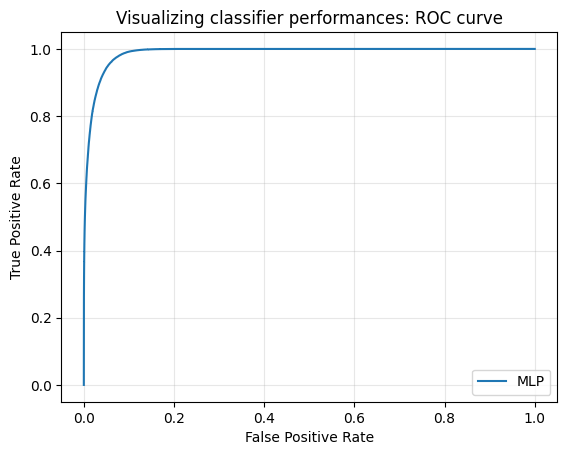

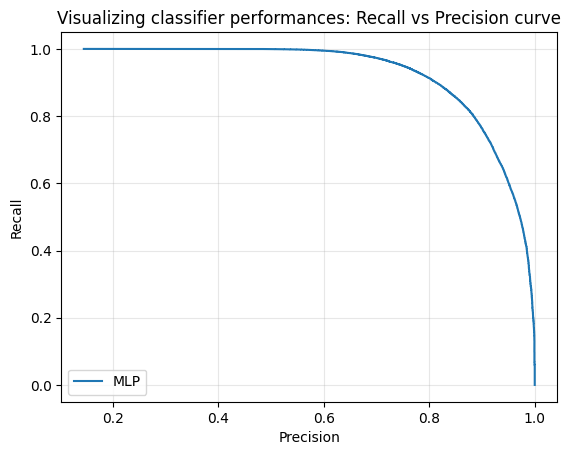

In [50]:
# Plotting performances
plt.plot(fpr_mlp, tpr_mlp, label="MLP")
plt.title("Visualizing classifier performances: ROC curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()
plt.close()

plt.plot(precision_mlp, recall_mlp, label="MLP")
plt.title("Visualizing classifier performances: Recall vs Precision curve")
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

In [51]:
report_dict = classification_report(y_true_torch, y_pred_torch, output_dict=True)
accuracy = report_dict.pop('accuracy')
df_report = pd.DataFrame(report_dict).transpose()
df_report = df_report.round(3)
print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.957


In [52]:
df_report

,precision,recall,f1-score,support
0,0.975,0.975,0.975,427742.0
1,0.854,0.850,0.852,72258.0
macro avg,0.914,0.913,0.914,500000.0
weighted avg,0.957,0.957,0.957,500000.0
